In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [6]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c dogs-vs-cats
!unzip -q dogs-vs-cats.zip
!unzip -q train.zip

100% 812M/812M [00:07<00:00, 120MB/s]



In [7]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Checking Dataset Integrity... (This might take a minute)
Cleaned! Valid Images: 25000 | Corrupted/Removed: 0


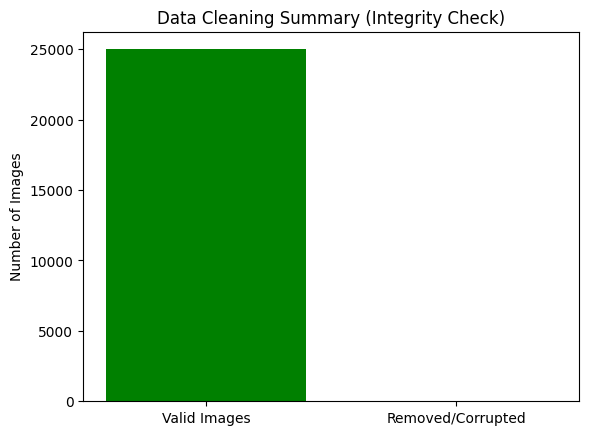

In [9]:
# --- Member 1: Data Cleaning & Integrity Check ---
import os
import cv2
import matplotlib.pyplot as plt

valid_extensions = ['.jpg', '.jpeg', '.png']
corrupted_count = 0
valid_count = 0

dataset_path = "/content/train"

print("Checking Dataset Integrity... (This might take a minute)")

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)

    if not any(file_path.lower().endswith(ext) for ext in valid_extensions):
        # Ensure it's a file before trying to remove, and handle directories
        if os.path.isfile(file_path):
            os.remove(file_path)
            corrupted_count += 1
        continue

    img = cv2.imread(file_path)
    if img is None:
        # Ensure it's a file before trying to remove, and handle directories
        if os.path.isfile(file_path):
            os.remove(file_path)
            corrupted_count += 1
    else:
        valid_count += 1

print(f"Cleaned! Valid Images: {valid_count} | Corrupted/Removed: {corrupted_count}")

plt.bar(['Valid Images', 'Removed/Corrupted'], [valid_count, corrupted_count], color=['green', 'red'])
plt.title('Data Cleaning Summary (Integrity Check)')
plt.ylabel('Number of Images')
plt.show()